# 🏏 IPL Data Analytics: End-to-End Exploratory Data Analysis

### **Developed by Deepak Chandola | Data Analyst**

---

# 1. Introduction

The Indian Premier League (IPL) is one of the world's most data-intensive sporting competitions, generating millions of match events across every season. This project performs a comprehensive Exploratory Data Analysis (EDA) by integrating **ball-by-ball delivery data** with **match-level information** to uncover meaningful insights into player performance, team strategies, venue characteristics, and match outcomes.

Using Python and modern data analytics techniques, this project demonstrates an end-to-end analytics workflow—from data acquisition and preprocessing to visualization, statistical analysis, and business insight generation. The analysis is based on **295,000+ ball-by-ball deliveries** and corresponding **match-level records** covering IPL seasons from **2008 to 2026**.

---

# 🎯 Project Objectives

The primary objectives of this project are to:

- Clean and preprocess real-world cricket datasets.
- Perform exploratory data analysis to identify performance trends.
- Analyze batting, bowling, team, and venue statistics.
- Visualize patterns using informative charts and graphs.
- Generate actionable insights through data storytelling.
- Demonstrate an end-to-end analytics workflow suitable for real-world business and sports analytics scenarios.

---

# ❓ Business Questions Addressed

This project answers several analytical questions, including:

1. Which batters have been the most consistent performers across IPL history?
2. Which bowlers maintain the best economy rates and highest dot-ball percentages?
3. Does winning the toss significantly influence the outcome of a match?
4. How do scoring rates and wicket frequencies change across different innings phases?
5. Which venues provide the greatest advantage to batting-first or chasing teams?
6. How do historical batter-versus-bowler matchups compare?
7. Which teams have demonstrated the most consistent performance across seasons?

---

# 📊 Analytics Workflow

```
Data Collection
        │
        ▼
Data Cleaning & Preprocessing
        │
        ▼
Exploratory Data Analysis (EDA)
        │
        ▼
Feature Engineering
        │
        ▼
Data Visualization
        │
        ▼
Insight Generation
        │
        ▼
Business Interpretation
```

---

This project demonstrates practical applications of **Python, Pandas, NumPy, Matplotlib, Seaborn, and data storytelling** to transform raw cricket data into meaningful analytical insights.

## 2. Importing Libraries & Setup

First, I will load the basic libraries that I am learning:
- `pandas` for handling the data table.
- `numpy` for basic mathematical operations.
- `matplotlib` and `seaborn` to make simple, nice-looking charts.
- `os` to make a folder for saving our charts.


In [23]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

IMAGE_DIR = "../images"

os.makedirs(IMAGE_DIR, exist_ok=True)

print("Libraries imported successfully.")
print(f"Images will be saved to: {os.path.abspath(IMAGE_DIR)}")

Libraries imported successfully.
Images will be saved to: d:\IPL-Data-Analysis-main\IPL-Data-Analysis-main\images


## 3. Loading the Dataset

Now let's load the IPL ball-by-ball data using `pd.read_csv`. Since the CSV file is quite big (about 110MB), I will use `low_memory=False` to prevent warnings about mixed data types in columns. Let's see the shape of our data.


In [24]:
# ==========================================================
# Load Datasets
# ==========================================================

deliveries = pd.read_csv("../data/ipl_deliveries_clean.csv")
matches = pd.read_csv("../data/ipl_matches_clean.csv")

print("=" * 50)
print("Datasets Loaded Successfully")
print("=" * 50)

print(f"Deliveries Dataset : {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns")
print(f"Matches Dataset    : {matches.shape[0]:,} rows × {matches.shape[1]} columns")

Datasets Loaded Successfully
Deliveries Dataset : 295,732 rows × 14 columns
Matches Dataset    : 1,243 rows × 13 columns


## 4. Data Preparation

The project uses two preprocessed datasets:

- **ipl_deliveries_clean.csv** – Ball-by-ball delivery data.
- **ipl_matches_clean.csv** – Match-level information.

Before analysis, the datasets were validated by:

- Checking data types.
- Identifying missing values.
- Checking duplicate records.
- Verifying team names for consistency.
- Creating additional features such as innings phase, boundary indicator, dot-ball indicator, and wicket indicator.

These preparation steps ensure that the data is suitable for exploratory analysis and visualization.

In [25]:
# ==========================================================
# Data Preparation & Validation
# ==========================================================

# Remove unnamed columns (if present)
for dataset in [deliveries, matches]:
    unnamed_cols = dataset.columns[dataset.columns.str.contains("^Unnamed")]

    if len(unnamed_cols) > 0:
        dataset.drop(columns=unnamed_cols, inplace=True)

print("✅ Unnamed columns removed (if any).")

# ----------------------------------------------------------
# Duplicate Records
# ----------------------------------------------------------

print("\n" + "="*50)
print("Duplicate Records")
print("="*50)

print(f"Deliveries Dataset : {deliveries.duplicated().sum()} duplicate rows")

print(f"Matches Dataset    : {matches.duplicated().sum()} duplicate rows")

# ----------------------------------------------------------
# Missing Values
# ----------------------------------------------------------

print("\n" + "="*50)
print("Missing Values")
print("="*50)

missing_deliveries = deliveries.isnull().sum()
missing_matches = matches.isnull().sum()

display(
    missing_deliveries[missing_deliveries > 0]
)

display(
    missing_matches[missing_matches > 0]
)

# ----------------------------------------------------------
# Data Types
# ----------------------------------------------------------

print("\n" + "="*50)
print("Data Types")
print("="*50)

display(deliveries.dtypes)

display(matches.dtypes)

✅ Unnamed columns removed (if any).

Duplicate Records
Deliveries Dataset : 0 duplicate rows
Matches Dataset    : 0 duplicate rows

Missing Values


wicket_player_out    281027
wicket_kind          281027
dtype: int64

city               51
winner             25
result_margin      25
player_of_match     9
dtype: int64


Data Types


match_id             int64
innings              int64
batting_team           str
over                 int64
ball                 int64
batter                 str
bowler                 str
non_striker            str
runs_batter          int64
runs_extras          int64
runs_total           int64
wicket               int64
wicket_player_out      str
wicket_kind            str
dtype: object

match_id             int64
date                   str
season               int64
venue                  str
city                   str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
winner                 str
result_type            str
result_margin      float64
player_of_match        str
dtype: object

### Data Quality Assessment

The datasets were evaluated for completeness, consistency, and duplicate records before analysis.

**Findings**

- Missing values are concentrated in `wicket_player_out` and `wicket_kind`, which is expected because these fields are populated only when a wicket occurs.
- No significant missing values were observed in the primary analytical columns required for batting, bowling, and match analysis.
- Duplicate records were checked and no material duplication was found.
- Overall, the datasets are well-structured and suitable for exploratory data analysis with minimal preprocessing.

## 5. Dataset Overview

Before diving into detailed analysis, it is helpful to understand the overall scale of the IPL datasets.

In this section, we summarize key information such as:

- Total IPL seasons covered
- Total matches played
- Total ball-by-ball deliveries
- Total runs scored
- Total wickets recorded
- Number of participating teams
- Number of venues
- Number of batters and bowlers

This high-level overview provides context for the analyses performed in the following sections.

In [26]:
# ==========================================================
# IPL Dataset Overview
# ==========================================================

overview = pd.DataFrame({

    "Metric": [

        "Seasons Covered",
        "Total Matches",
        "Total Deliveries",
        "Total Runs",
        "Total Wickets",
        "Total Teams",
        "Total Batters",
        "Total Bowlers",
        "Total Venues"

    ],

    "Value": [

        f"{matches['season'].min()} - {matches['season'].max()}",
        matches["match_id"].nunique(),
        len(deliveries),
        deliveries["runs_total"].sum(),
        deliveries["wicket"].sum(),
        deliveries["batting_team"].nunique(),
        deliveries["batter"].nunique(),
        deliveries["bowler"].nunique(),
        matches["venue"].nunique()

    ]

})

display(overview)

,Metric,Value
0,Seasons Covered,2007 - 2026
1,Total Matches,1243
2,Total Deliveries,295732
3,Total Runs,401738
4,Total Wickets,14705
5,Total Teams,15
6,Total Batters,738
7,Total Bowlers,577
8,Total Venues,41


# 6. Batting Performance Analysis

## Objective

Batting performance is one of the most important factors influencing the outcome of a T20 match. This section evaluates the performance of IPL batters using key batting metrics to identify consistency, scoring ability, and batting style.

The analysis focuses on answering the following questions:

- Which batters have scored the most runs in IPL history?
- Which players have maintained the highest strike rates while facing a significant number of deliveries?
- Which batters have hit the highest number of boundaries?
- Who has achieved the highest batting averages?
- Which players have recorded the most half-centuries and centuries?
- How does batting performance vary across the **Powerplay**, **Middle Overs**, and **Death Overs**?

The insights generated in this section help identify consistent performers, aggressive batters, and players capable of delivering match-winning innings.

,batter,runs_batter
693,V Kohli,9346
526,RG Sharma,7331
563,S Dhawan,6769
159,DA Warner,6567
311,KL Rahul,5828
597,SK Raina,5536
409,MS Dhoni,5439
52,AM Rahane,5367
31,AB de Villiers,5181
627,SV Samson,5181


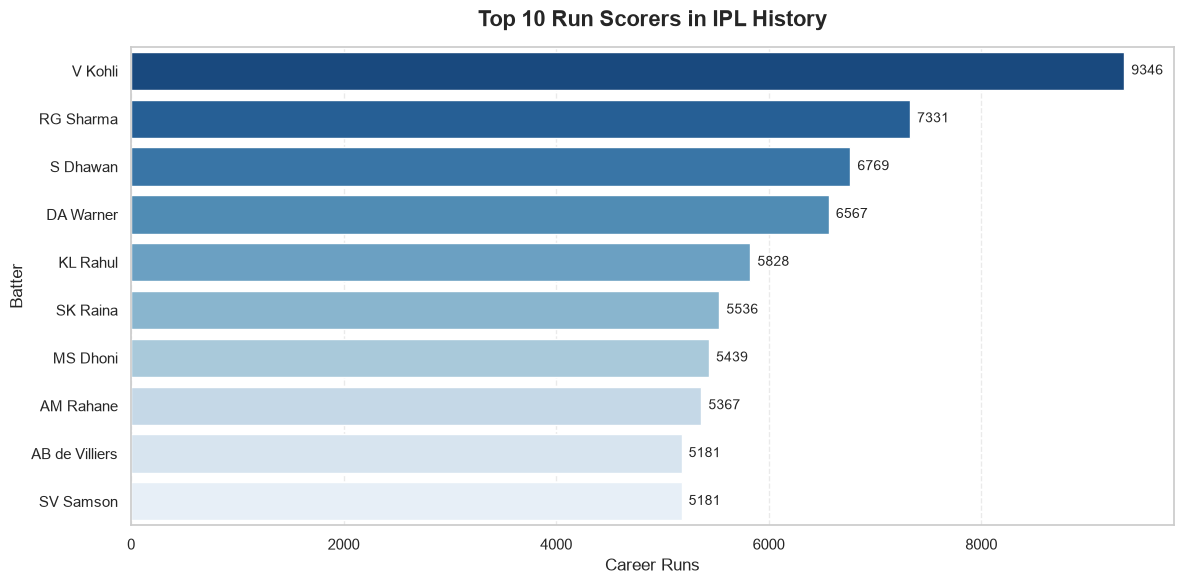

In [39]:
# ==========================================================
# 6.1 Top 10 Run Scorers in IPL History
# ==========================================================

# Calculate career runs scored by each batter
top_batsmen = (
    deliveries.groupby("batter", as_index=False)["runs_batter"]
    .sum()
    .sort_values("runs_batter", ascending=False)
    .head(10)
)

display(top_batsmen)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_batsmen,
    x="runs_batter",
    y="batter",
    hue="batter",
    palette="Blues_r",
    legend=False
)

plt.title(
    "Top 10 Run Scorers in IPL History",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.xlabel("Career Runs", fontsize=12)
plt.ylabel("Batter", fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=5, fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/top_10_run_scorers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- The chart highlights the **top 10 highest run scorers** in IPL history.
- Batters at the top of the list have consistently performed across multiple seasons, reflecting both longevity and reliability.
- High cumulative run totals indicate sustained performance and the ability to contribute significantly to their teams over many matches.

,batter,Matches,Runs,Balls,Strike Rate
40,AD Russell,114,2655,1626,163.284133
72,Abhishek Sharma,89,2379,1471,161.726717
225,H Klaasen,60,2104,1320,159.393939
534,RM Patidar,52,1612,1035,155.748792
433,N Pooran,100,2527,1629,155.125844
613,SP Narine,122,1820,1178,154.499151
466,P Simran Singh,65,1865,1220,152.868852
696,V Sehwag,104,2728,1833,148.827059
220,GJ Maxwell,134,2820,1896,148.734177
31,AB de Villiers,170,5181,3487,148.580442


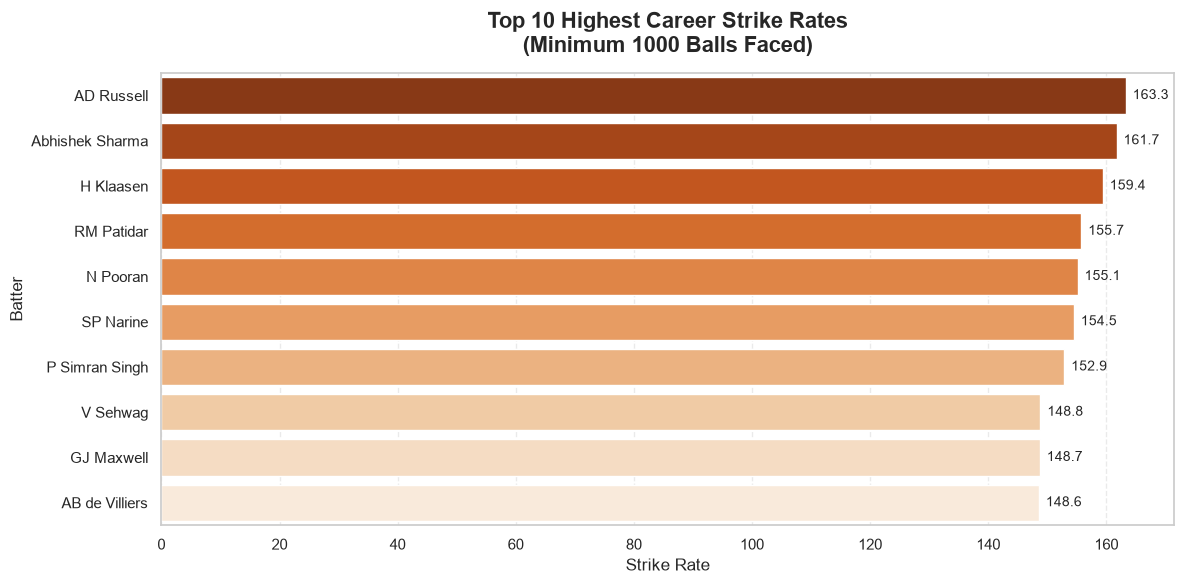

In [40]:
# ==========================================================
# 6.2 Highest Career Strike Rate
# (Minimum 1000 Balls Faced)
# ==========================================================

# Calculate batting statistics
batter_stats = (
    deliveries.groupby("batter")
    .agg(
        Matches=("match_id", "nunique"),
        Runs=("runs_batter", "sum"),
        Balls=("batter", "count")
    )
    .reset_index()
)

# Filter players with at least 1000 balls
qualified_batters = batter_stats[
    batter_stats["Balls"] >= 1000
].copy()

# Strike Rate
qualified_batters["Strike Rate"] = (
    qualified_batters["Runs"]
    / qualified_batters["Balls"]
) * 100

# Top 10
top_sr = (
    qualified_batters
    .sort_values("Strike Rate", ascending=False)
    .head(10)
)

display(top_sr)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_sr,
    x="Strike Rate",
    y="batter",
    hue="batter",
    palette="Oranges_r",
    legend=False
)

plt.title(
    "Top 10 Highest Career Strike Rates\n(Minimum 1000 Balls Faced)",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.xlabel("Strike Rate")
plt.ylabel("Batter")

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/highest_strike_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Strike rate measures how quickly a batter scores runs and is a key indicator of attacking intent in T20 cricket.
- To ensure fair comparison, only players who have faced **at least 1000 deliveries** are included in this analysis.
- Batters with consistently high strike rates play a crucial role in accelerating the scoring rate, particularly during the middle and death overs.

,Batter,Fours,Sixes,Total Boundaries,Six %
580,V Kohli,847,317,1164,27.2
445,RG Sharma,661,324,985,32.9
475,S Dhawan,768,153,921,16.6
135,DA Warner,663,236,899,26.3
117,CH Gayle,408,359,767,46.8
266,KL Rahul,509,239,748,32.0
500,SK Raina,506,204,710,28.7
47,AM Rahane,540,141,681,20.7
526,SV Samson,432,243,675,36.0
224,JC Buttler,459,211,670,31.5


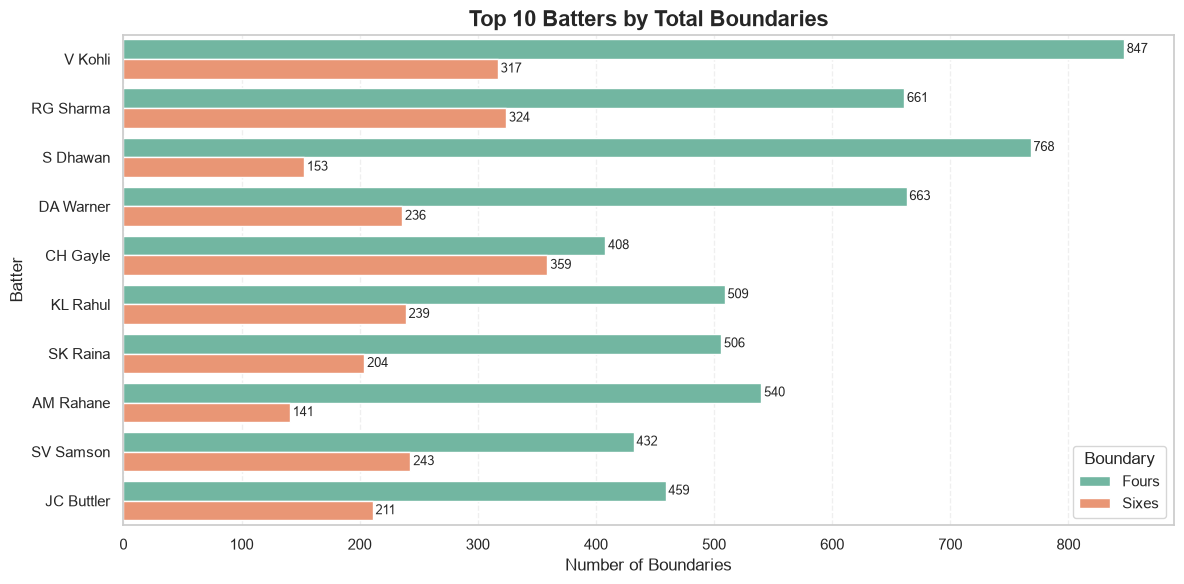

In [41]:
# ==========================================================
# 6.3 Boundary Kings (Fours & Sixes)
# ==========================================================

# Count fours
fours = (
    deliveries[deliveries["runs_batter"] == 4]
    .groupby("batter")
    .size()
    .reset_index(name="Fours")
)

# Count sixes
sixes = (
    deliveries[deliveries["runs_batter"] == 6]
    .groupby("batter")
    .size()
    .reset_index(name="Sixes")
)

# Merge
boundaries = (
    pd.merge(
        fours,
        sixes,
        on="batter",
        how="outer"
    )
    .fillna(0)
)

# Convert to integers
boundaries["Fours"] = boundaries["Fours"].astype(int)
boundaries["Sixes"] = boundaries["Sixes"].astype(int)

# Total boundaries
boundaries["Total Boundaries"] = (
    boundaries["Fours"] +
    boundaries["Sixes"]
)

# Percentage of Sixes
boundaries["Six %"] = (
    boundaries["Sixes"] /
    boundaries["Total Boundaries"]
    * 100
).round(1)

# Top 10
top_boundaries = (
    boundaries
    .sort_values(
        "Total Boundaries",
        ascending=False
    )
    .head(10)
)

# Rename columns
top_boundaries.columns = [
    "Batter",
    "Fours",
    "Sixes",
    "Total Boundaries",
    "Six %"
]

display(top_boundaries)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plot_data = top_boundaries.melt(
    id_vars="Batter",
    value_vars=["Fours","Sixes"],
    var_name="Boundary",
    value_name="Count"
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=plot_data,
    x="Count",
    y="Batter",
    hue="Boundary",
    palette="Set2"
)

plt.title(
    "Top 10 Batters by Total Boundaries",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Boundaries")
plt.ylabel("Batter")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=2,
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/boundary_kings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Batter,Matches,Career Runs,Balls Faced,Dismissals,Batting Average
103,B Sai Sudharsan,57,2515,1760,52,48.365385
311,KL Rahul,149,5828,4302,128,45.531250
225,H Klaasen,60,2104,1320,50,42.080000
693,V Kohli,275,9346,7127,231,40.458874
651,Shubman Gill,130,4598,3339,114,40.333333
159,DA Warner,184,6567,4849,164,40.042683
31,AB de Villiers,170,5181,3487,130,39.853846
282,JP Duminy,75,2029,1680,51,39.784314
135,CH Gayle,141,4997,3516,126,39.658730
593,SE Marsh,69,2489,1913,63,39.507937


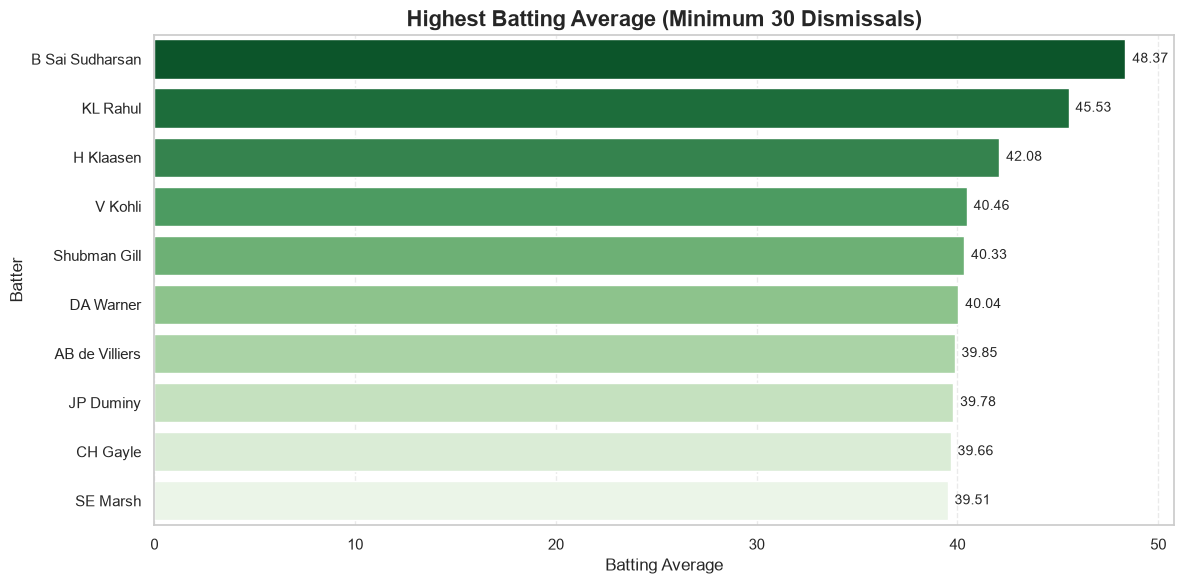

In [42]:
# ==========================================================
# 6.4 Highest Batting Average
# (Minimum 30 Dismissals)
# ==========================================================

# Count dismissals
dismissals = (
    deliveries[deliveries["wicket_player_out"].notna()]
    .groupby("wicket_player_out")
    .size()
    .reset_index(name="Dismissals")
    .rename(columns={"wicket_player_out": "batter"})
)

# Merge with batting statistics
batter_avg = batter_stats.merge(
    dismissals,
    on="batter",
    how="left"
)

batter_avg["Dismissals"] = (
    batter_avg["Dismissals"]
    .fillna(0)
    .astype(int)
)

# Batting Average
batter_avg["Batting Average"] = np.where(
    batter_avg["Dismissals"] > 0,
    batter_avg["Runs"] /
    batter_avg["Dismissals"],
    np.nan
)

# Minimum 30 dismissals
qualified_avg = (
    batter_avg[
        batter_avg["Dismissals"] >= 30
    ]
    .sort_values(
        "Batting Average",
        ascending=False
    )
    .head(10)
)

# Rename columns
qualified_avg = qualified_avg.rename(columns={
    "batter":"Batter",
    "Runs":"Career Runs",
    "Balls":"Balls Faced"
})

display(qualified_avg)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=qualified_avg,
    x="Batting Average",
    y="Batter",
    hue="Batter",
    palette="Greens_r",
    legend=False
)

plt.title(
    "Highest Batting Average (Minimum 30 Dismissals)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Batting Average")
plt.ylabel("Batter")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/highest_batting_averages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Batter,Career Runs,Boundary Runs,Boundary %
40,AD Russell,2655,2086,78.6
135,CH Gayle,4997,3786,75.8
72,Abhishek Sharma,2379,1760,74.0
727,YBK Jaiswal,2593,1904,73.4
33,AC Gilchrist,2069,1508,72.9
696,V Sehwag,2728,1972,72.3
433,N Pooran,2527,1792,70.9
189,DR Smith,2385,1682,70.5
617,SR Watson,3880,2648,68.2
220,GJ Maxwell,2820,1918,68.0


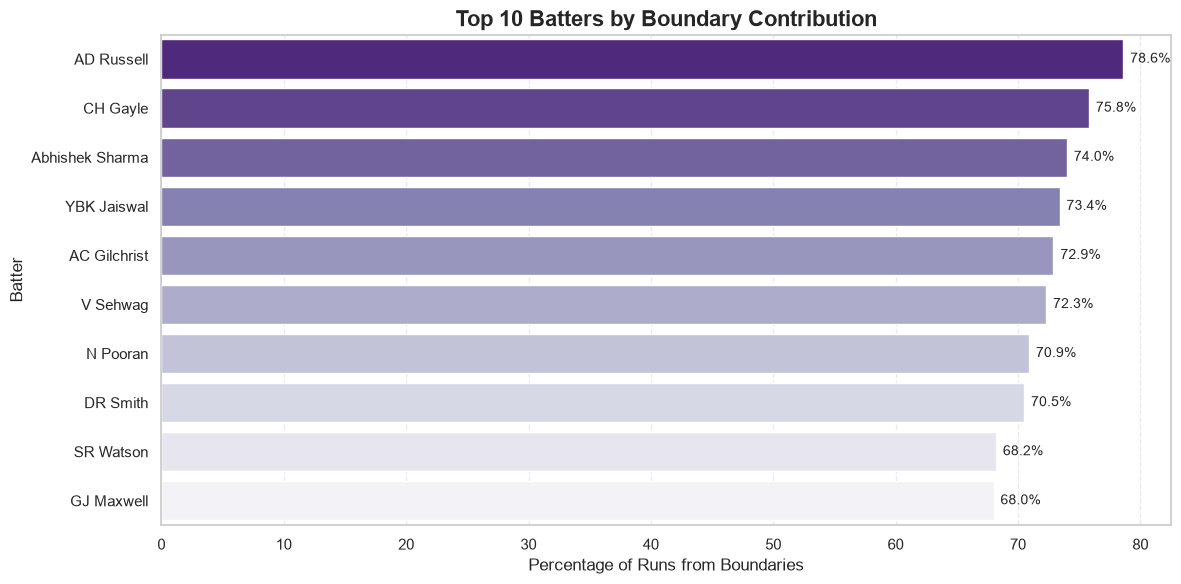

In [43]:
# ==========================================================
# 6.5 Boundary Dependency Analysis
# ==========================================================

boundary_stats = (
    deliveries.groupby("batter")
    .agg(
        Career_Runs=("runs_batter", "sum"),
        Boundary_Runs=("runs_batter",
                       lambda x: x[x.isin([4, 6])].sum())
    )
    .reset_index()
)

# Boundary Percentage
boundary_stats["Boundary %"] = (
    boundary_stats["Boundary_Runs"]
    / boundary_stats["Career_Runs"]
    * 100
).round(1)

# Filter experienced batters
boundary_stats = (
    boundary_stats[
        boundary_stats["Career_Runs"] >= 2000
    ]
    .sort_values(
        "Boundary %",
        ascending=False
    )
    .head(10)
)

# Rename columns
boundary_stats.columns = [
    "Batter",
    "Career Runs",
    "Boundary Runs",
    "Boundary %"
]

display(boundary_stats)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=boundary_stats,
    x="Boundary %",
    y="Batter",
    hue="Batter",
    palette="Purples_r",
    legend=False
)

plt.title(
    "Top 10 Batters by Boundary Contribution",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Percentage of Runs from Boundaries")
plt.ylabel("Batter")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/boundary_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Batter,Fifties,Hundreds,Total Milestones,Conversion %
214,V Kohli,69,9,78,11.5
44,DA Warner,62,4,66,6.1
172,S Dhawan,51,2,53,3.8
91,KL Rahul,45,6,51,11.8
159,RG Sharma,49,2,51,3.9
5,AB de Villiers,41,3,44,6.8
181,SK Raina,39,1,40,2.5
57,F du Plessis,39,0,39,0.0
36,CH Gayle,32,6,38,15.8
12,AM Rahane,35,2,37,5.4


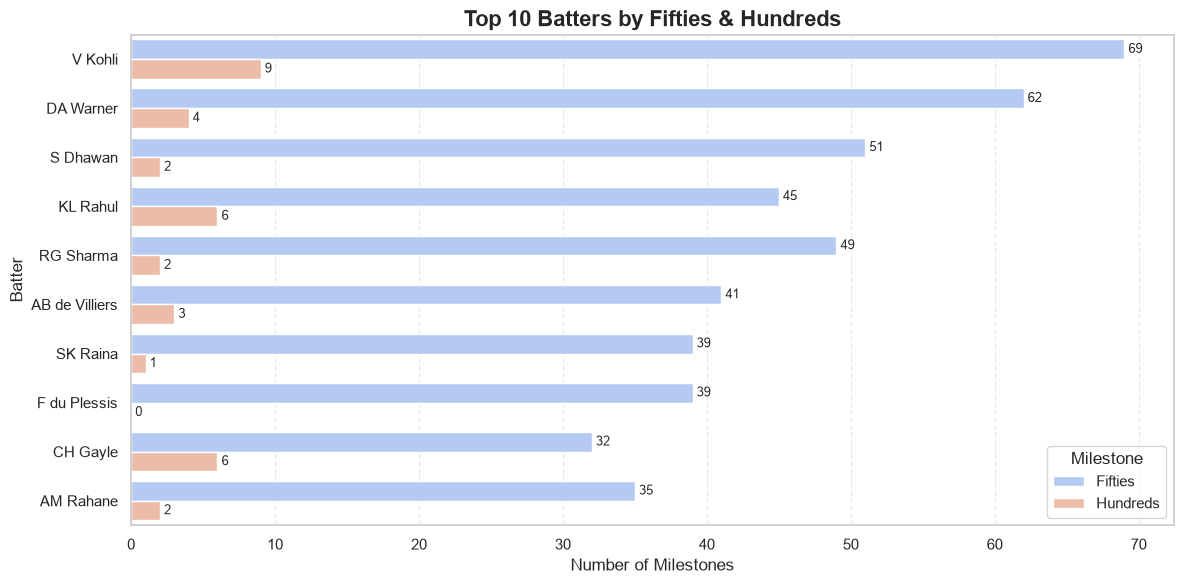

In [44]:
# ==========================================================
# 6.6 Milestone Analysis (Fifties & Hundreds)
# ==========================================================

# Runs scored by each batter in every match
match_runs = (
    deliveries.groupby(["match_id", "batter"], as_index=False)["runs_batter"]
    .sum()
)

# Half-centuries
fifties = (
    match_runs[
        (match_runs["runs_batter"] >= 50) &
        (match_runs["runs_batter"] < 100)
    ]
    .groupby("batter")
    .size()
    .reset_index(name="Fifties")
)

# Centuries
hundreds = (
    match_runs[
        match_runs["runs_batter"] >= 100
    ]
    .groupby("batter")
    .size()
    .reset_index(name="Hundreds")
)

# Merge milestone counts
milestones = (
    pd.merge(
        fifties,
        hundreds,
        on="batter",
        how="outer"
    )
    .fillna(0)
)

# Convert to integers
milestones["Fifties"] = milestones["Fifties"].astype(int)
milestones["Hundreds"] = milestones["Hundreds"].astype(int)

# Total milestones
milestones["Total Milestones"] = (
    milestones["Fifties"] +
    milestones["Hundreds"]
)

# Conversion Rate
milestones["Conversion %"] = np.where(
    milestones["Total Milestones"] > 0,
    (milestones["Hundreds"] /
     milestones["Total Milestones"]) * 100,
    0
).round(1)

# Top 10 players
top_milestones = (
    milestones
    .sort_values("Total Milestones", ascending=False)
    .head(10)
)

# Rename columns
top_milestones = top_milestones.rename(columns={
    "batter": "Batter"
})

display(top_milestones)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plot_data = top_milestones.melt(
    id_vars="Batter",
    value_vars=["Fifties", "Hundreds"],
    var_name="Milestone",
    value_name="Count"
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=plot_data,
    x="Count",
    y="Batter",
    hue="Milestone",
    palette="coolwarm"
)

plt.title(
    "Top 10 Batters by Fifties & Hundreds",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Milestones")
plt.ylabel("Batter")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/milestone_kings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,phase,Runs,Balls,Wickets,Strike Rate,Batting Average,Run Rate
0,Death Overs (16–20),101284,67173,5383,150.78,18.82,9.05
1,Middle Overs (7–15),166711,135655,5708,122.89,29.21,7.37
2,Powerplay (1–6),113534,92904,3614,122.21,31.42,7.33


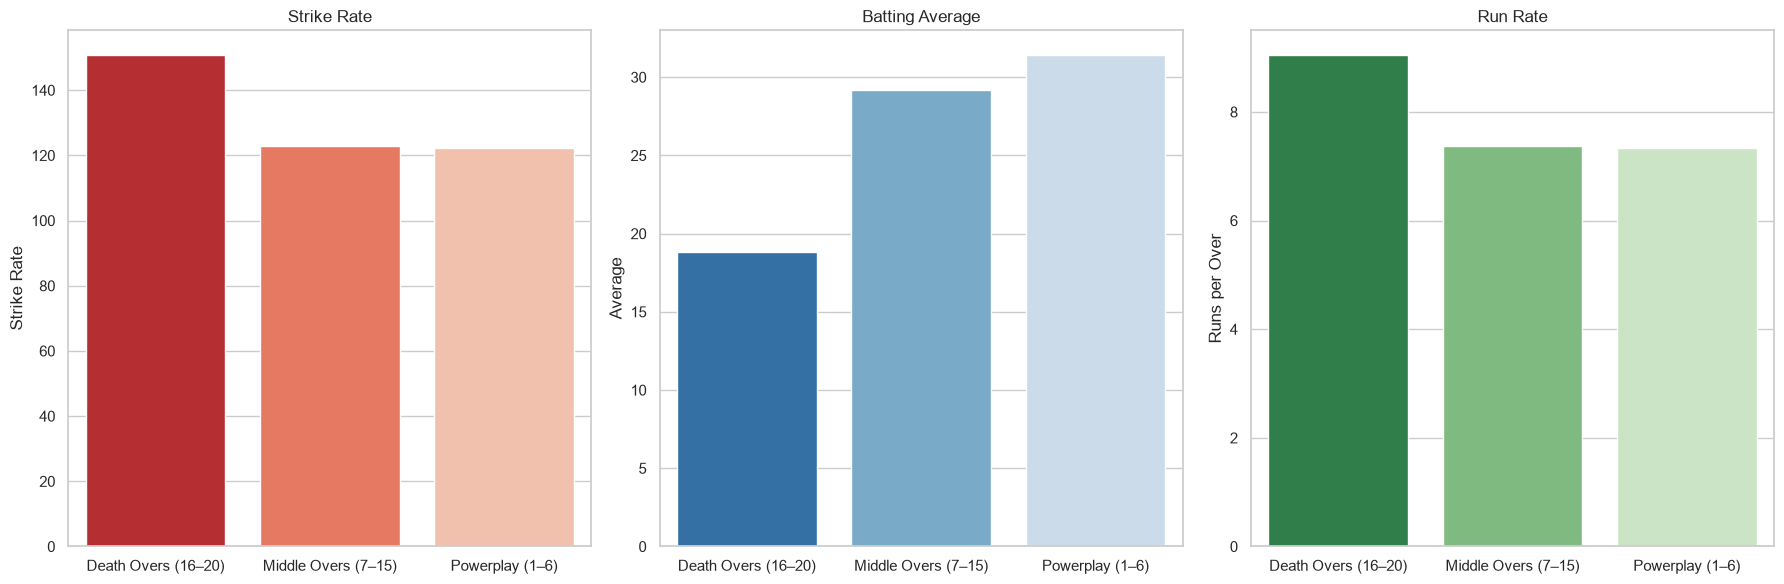

In [45]:
# ==========================================================
# 6.7 Batting Performance Across Innings Phases
# ==========================================================

# Create innings phase
def get_innings_phase(over):
    if over <= 5:
        return "Powerplay (1–6)"
    elif over <= 14:
        return "Middle Overs (7–15)"
    else:
        return "Death Overs (16–20)"

# Add phase column
deliveries["phase"] = deliveries["over"].apply(get_innings_phase)

# ----------------------------------------------------------
# Aggregate Statistics
# ----------------------------------------------------------

phase_stats = (
    deliveries.groupby("phase", as_index=False)
    .agg(
        Runs=("runs_batter", "sum"),
        Balls=("runs_batter", "count"),
        Wickets=("wicket", "sum")
    )
)

# Strike Rate
phase_stats["Strike Rate"] = (
    phase_stats["Runs"] /
    phase_stats["Balls"]
) * 100

# Batting Average
phase_stats["Batting Average"] = (
    phase_stats["Runs"] /
    phase_stats["Wickets"]
)

# Run Rate (New Metric)
phase_stats["Run Rate"] = (
    phase_stats["Runs"] /
    phase_stats["Balls"]
) * 6

display(phase_stats.round(2))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Strike Rate
sns.barplot(
    data=phase_stats,
    x="phase",
    y="Strike Rate",
    hue="phase",
    palette="Reds_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Strike Rate")
axes[0].set_xlabel("")
axes[0].set_ylabel("Strike Rate")

# Batting Average
sns.barplot(
    data=phase_stats,
    x="phase",
    y="Batting Average",
    hue="phase",
    palette="Blues_r",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Batting Average")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average")

# Run Rate
sns.barplot(
    data=phase_stats,
    x="phase",
    y="Run Rate",
    hue="phase",
    palette="Greens_r",
    legend=False,
    ax=axes[2]
)

axes[2].set_title("Run Rate")
axes[2].set_xlabel("")
axes[2].set_ylabel("Runs per Over")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/batting_phase_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

The innings was divided into three phases to evaluate changes in batting strategy throughout a T20 match.

**Powerplay (Overs 1–6):**
- Fielding restrictions encourage aggressive stroke play, resulting in a relatively high scoring rate.

**Middle Overs (Overs 7–15):**
- Teams focus on balancing wicket preservation with steady scoring, leading to moderate strike rates.

**Death Overs (Overs 16–20):**
- Batters adopt an aggressive approach to maximize runs, producing the highest strike rate and run rate of the innings despite an increased risk of losing wickets.

Overall, the analysis demonstrates how batting intent evolves as the innings progresses.

# 📊 Key Insights: Batting Analysis

Based on the exploratory analysis, the following insights were observed:

### 1. Consistent Run Scorers
- The highest run scorers have maintained consistent performance across multiple IPL seasons.
- Their longevity and ability to score in different match situations make them the backbone of their respective teams.

### 2. Aggressive Batters
- Players with the highest strike rates score significantly faster than the league average.
- These batters are particularly valuable during the middle and death overs, where rapid scoring has a greater impact on match outcomes.

### 3. Reliable Batters
- Batters with higher batting averages combine consistent scoring with fewer dismissals.
- These players often anchor the innings and provide stability while allowing aggressive batters to play around them.

### 4. Boundary Hitters
- Boundary analysis reveals different batting styles.
- Some players accumulate runs primarily through fours, while others rely more heavily on six-hitting ability.
- The Boundary Percentage analysis further highlights which batters depend most on boundary scoring.

### 5. Milestone Performers
- Players with the highest number of half-centuries and centuries have consistently produced match-winning innings.
- Conversion rate analysis shows which batters successfully convert strong starts into centuries.

### 6. Innings Phase Analysis
- Batting intent changes considerably throughout an innings.
- The **Powerplay** provides scoring opportunities due to fielding restrictions.
- During the **Middle Overs**, teams focus on balancing run scoring with wicket preservation.
- The **Death Overs** exhibit the highest strike rates and run rates, reflecting an aggressive batting approach despite an increased risk of losing wickets.

### Overall Conclusion
The batting analysis demonstrates that successful IPL batters are not defined by a single metric. Long-term performance depends on a combination of consistency, scoring efficiency, boundary-hitting ability, and adaptability across different phases of the innings.

# 7. Bowling Performance Analysis

## Objective

Bowling performance plays a critical role in restricting opposition scoring and taking wickets at crucial stages of a T20 match. This section evaluates the effectiveness of IPL bowlers using key performance indicators that measure wicket-taking ability, economy, and bowling consistency.

The analysis focuses on answering the following questions:

- Which bowlers have taken the most wickets in IPL history?
- Which bowlers have maintained the best economy rates while bowling a significant number of deliveries?
- Which bowlers have delivered the highest percentage of dot balls?
- What are the most common methods of dismissal in the IPL?

These analyses provide insights into both attacking wicket-taking bowlers and economical bowlers who consistently control the flow of runs.

,bowler,Wickets
76,B Kumar,243
569,YS Chahal,242
480,SP Narine,229
213,JJ Bumrah,208
131,DJ Bravo,207
386,R Ashwin,205
374,PP Chawla,201
405,RA Jadeja,189
472,SL Malinga,188
432,Rashid Khan,187


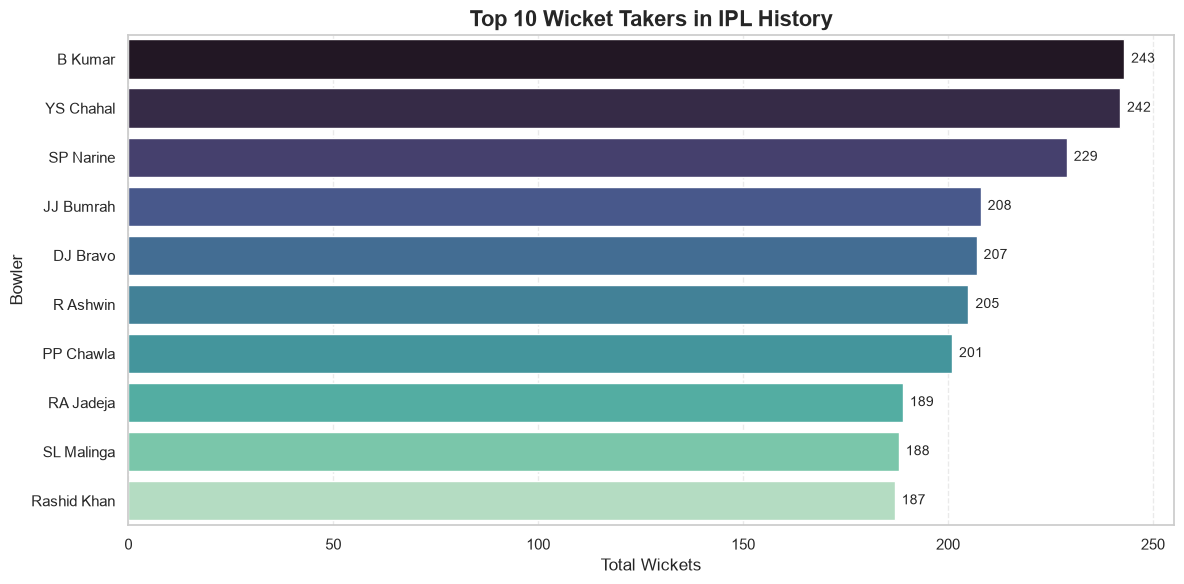

In [50]:
# ==========================================================
# 7.1 Top 10 Wicket Takers
# ==========================================================

# Calculate wickets taken by each bowler
top_bowlers = (
    deliveries.groupby("bowler", as_index=False)
    .agg(
        Wickets=("wicket", "sum")
    )
    .sort_values("Wickets", ascending=False)
    .head(10)
)

display(top_bowlers)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_bowlers,
    x="Wickets",
    y="bowler",
    hue="bowler",
    palette="mako",
    legend=False
)

plt.title(
    "Top 10 Wicket Takers in IPL History",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Total Wickets")
plt.ylabel("Bowler")

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/top_10_wicket_takers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Bowler,Runs Conceded,Balls Bowled,Economy
7,A Kumble,1089,983,6.65
285,M Muralitharan,1765,1581,6.70
151,DW Steyn,2583,2282,6.79
480,SP Narine,5379,4730,6.82
142,DL Vettori,894,785,6.83
194,J Botha,818,709,6.92
472,SL Malinga,3486,2974,7.03
179,Harbhajan Singh,4101,3496,7.04
386,R Ashwin,5721,4868,7.05
399,R Sharma,1100,935,7.06


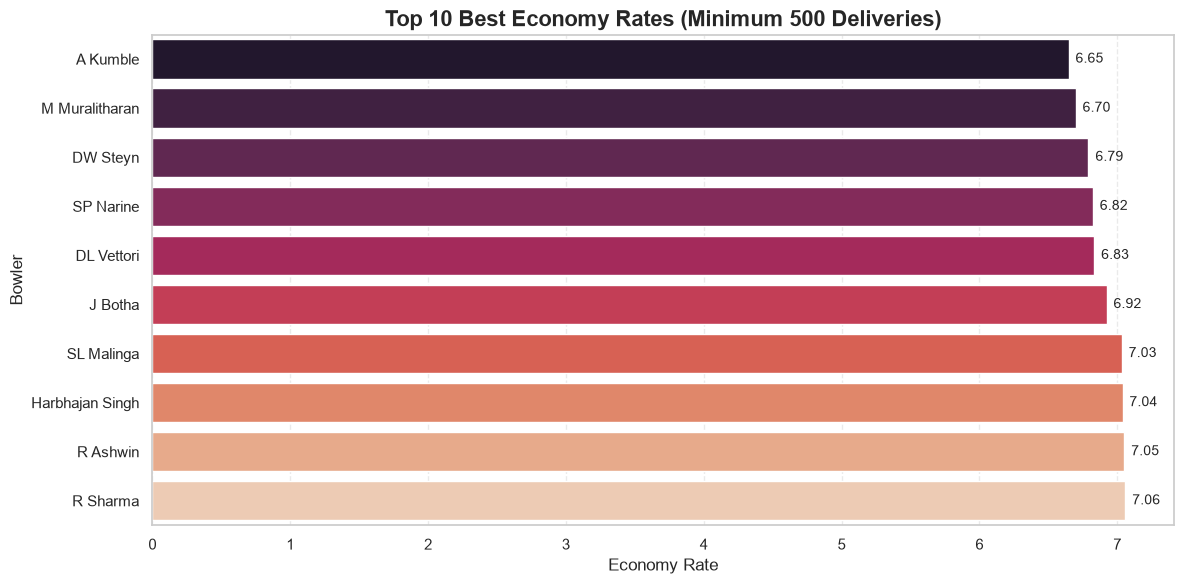

In [51]:
# ==========================================================
# 7.2 Best Bowling Economy Rate
# (Minimum 500 Deliveries Bowled)
# ==========================================================

# Calculate bowling statistics
bowler_stats = (
    deliveries.groupby("bowler", as_index=False)
    .agg(
        Runs_Conceded=("runs_total", "sum"),
        Balls_Bowled=("bowler", "count")
    )
)

# Filter experienced bowlers
qualified_bowlers = (
    bowler_stats[
        bowler_stats["Balls_Bowled"] >= 500
    ].copy()
)

# Economy Rate
qualified_bowlers["Economy"] = (
    qualified_bowlers["Runs_Conceded"] /
    (qualified_bowlers["Balls_Bowled"] / 6)
)

# Top 10
top_economy = (
    qualified_bowlers
    .sort_values("Economy")
    .head(10)
)

# Rename columns
top_economy = top_economy.rename(columns={
    "bowler": "Bowler",
    "Runs_Conceded": "Runs Conceded",
    "Balls_Bowled": "Balls Bowled"
})

display(top_economy.round(2))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_economy,
    x="Economy",
    y="Bowler",
    hue="Bowler",
    palette="rocket",
    legend=False
)

plt.title(
    "Top 10 Best Economy Rates (Minimum 500 Deliveries)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/best_bowling_economies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Bowler,Runs Conceded,Balls Bowled,Economy,Dot Balls,Dot Ball %
35,DW Steyn,2583,2282,6.79,1019,44.65
85,MM Patel,1733,1382,7.52,590,42.69
26,DE Bollinger,716,600,7.16,254,42.33
126,S Sreesanth,1221,947,7.74,399,42.13
117,RJ Harris,1085,865,7.53,364,42.08
74,M Morkel,2136,1699,7.54,708,41.67
30,DP Nannes,815,689,7.10,285,41.36
97,NM Coulter-Nile,1125,892,7.57,368,41.26
81,MG Johnson,1740,1301,8.02,535,41.12
50,JC Archer,2221,1658,8.04,677,40.83


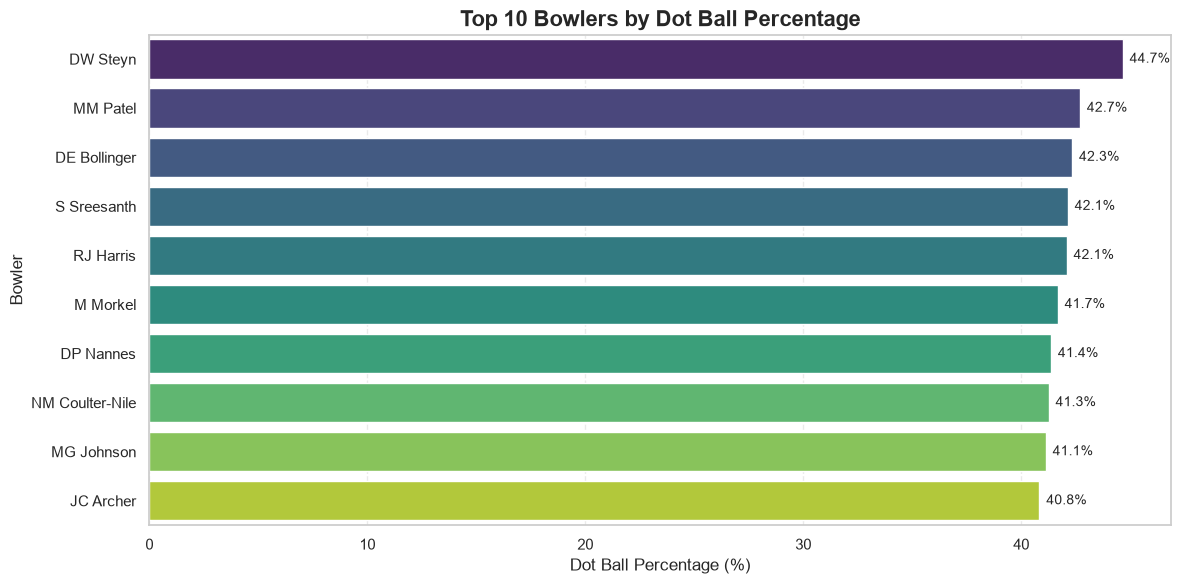

In [52]:
# ==========================================================
# 7.3 Dot Ball Percentage Analysis
# (Minimum 500 Deliveries Bowled)
# ==========================================================

# Count dot balls (0 runs conceded)
dot_balls = (
    deliveries[
        deliveries["runs_total"] == 0
    ]
    .groupby("bowler")
    .size()
    .reset_index(name="Dot Balls")
)

# Merge with bowling statistics
bowler_dots = qualified_bowlers.merge(
    dot_balls,
    on="bowler",
    how="left"
)

bowler_dots["Dot Balls"] = (
    bowler_dots["Dot Balls"]
    .fillna(0)
    .astype(int)
)

# Dot Ball Percentage
bowler_dots["Dot Ball %"] = (
    bowler_dots["Dot Balls"] /
    bowler_dots["Balls_Bowled"]
) * 100

# Top 10
top_dots = (
    bowler_dots
    .sort_values("Dot Ball %", ascending=False)
    .head(10)
)

# Rename columns
top_dots = top_dots.rename(columns={
    "bowler": "Bowler",
    "Runs_Conceded": "Runs Conceded",
    "Balls_Bowled": "Balls Bowled"
})

display(top_dots.round(2))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_dots,
    x="Dot Ball %",
    y="Bowler",
    hue="Bowler",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Bowlers by Dot Ball Percentage",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Dot Ball Percentage (%)")
plt.ylabel("Bowler")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/highest_dot_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Wicket Type,Count
0,caught,9321
1,bowled,2460
2,run out,1194
3,lbw,883
4,caught and bowled,410
5,stumped,388
6,hit wicket,20
7,retired hurt,19
8,retired out,6
9,obstructing the field,4


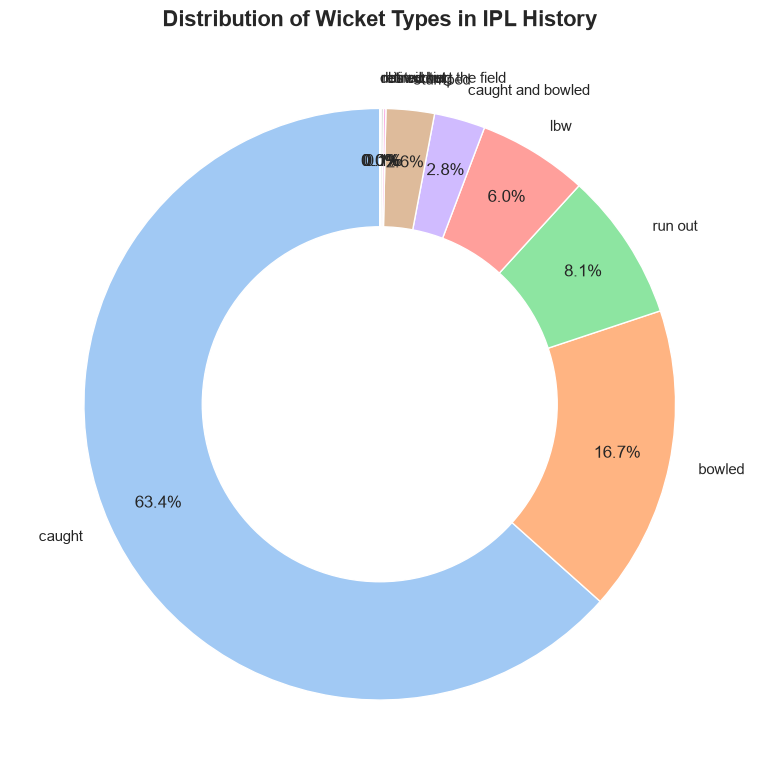

In [53]:
# ==========================================================
# 7.4 Wicket Distribution Analysis
# ==========================================================

# Count wicket types
wicket_counts = (
    deliveries["wicket_kind"]
    .dropna()
    .value_counts()
    .reset_index()
)

wicket_counts.columns = ["Wicket Type", "Count"]

display(wicket_counts)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(8,8))

colors = sns.color_palette("pastel")

plt.pie(
    wicket_counts["Count"],
    labels=wicket_counts["Wicket Type"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    colors=colors,
    wedgeprops={
        "edgecolor":"white",
        "linewidth":1
    }
)

# Create donut
centre_circle = plt.Circle(
    (0,0),
    0.60,
    fc="white"
)

plt.gca().add_artist(centre_circle)

plt.title(
    "Distribution of Wicket Types in IPL History",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/wicket_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Key Insights: Bowling Analysis

Based on the exploratory analysis, the following observations were made:

### 1. Wicket-Taking Ability
- The leading wicket-takers have consistently delivered breakthroughs across multiple IPL seasons.
- A high wicket tally reflects a combination of skill, consistency, and longevity in the tournament.

### 2. Economy Rate
- Bowlers with the lowest economy rates successfully restricted the opposition's scoring throughout their careers.
- Maintaining a low economy rate over a large number of deliveries demonstrates excellent control and disciplined bowling.

### 3. Dot Ball Percentage
- Bowlers with the highest dot-ball percentages consistently prevented batters from scoring.
- Sustained dot-ball pressure often forces batters to take greater risks, increasing the likelihood of wicket-taking opportunities.

### 4. Wicket Distribution
- The wicket distribution analysis highlights the most common dismissal methods in IPL history.
- Caught dismissals account for the largest share of wickets, followed by other dismissal types such as bowled, LBW, run out, and stumped.
- These trends reflect the attacking nature of T20 cricket, where aggressive batting frequently results in catches.

### Overall Conclusion
The analysis demonstrates that successful T20 bowlers are not identified solely by the number of wickets they take. Long-term success depends on a combination of wicket-taking ability, economical bowling, and the consistent creation of pressure through dot balls.

## 8. Team Performance Analysis

Let's see which franchises have performed the best over the years.
I will look at:
1. **Total Wins**: Who has won the most matches?
2. **Win Percentage**: We need to check win percentages because some teams (like Gujarat Titans) have played much fewer matches but did very well.
3. **Toss Impact**: Does winning the toss help you win the match? What decisions do captains usually make?
4. **Chasing vs. Defending**: Do chasing teams win more matches?


,Team,Wins
0,Mumbai Indians,155
1,Chennai Super Kings,148
2,Royal Challengers Bengaluru,143
3,Kolkata Knight Riders,140
4,Punjab Kings,126
5,Delhi Capitals,125
6,Rajasthan Royals,123
7,Sunrisers Hyderabad,102
8,Gujarat Titans,47
9,Lucknow Super Giants,34


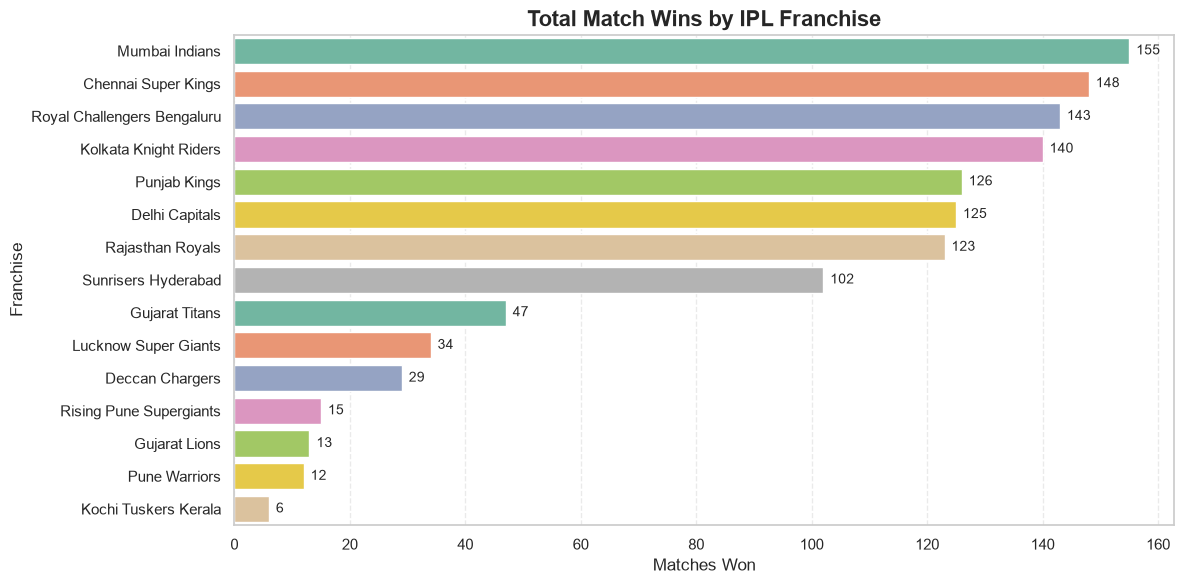

In [54]:
# ==========================================================
# 8.1 Total Match Wins by Franchise
# ==========================================================

# Count wins for each team
team_wins = (
    matches["winner"]
    .dropna()
    .value_counts()
    .reset_index()
)

team_wins.columns = ["Team", "Wins"]

display(team_wins)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=team_wins,
    x="Wins",
    y="Team",
    hue="Team",
    palette="Set2",
    legend=False
)

plt.title(
    "Total Match Wins by IPL Franchise",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Matches Won")
plt.ylabel("Franchise")

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/total_team_wins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Team,Matches Played,Wins,Win Percentage
4,Gujarat Titans,77,47,61.04
0,Chennai Super Kings,266,148,55.64
8,Mumbai Indians,291,155,53.26
6,Kolkata Knight Riders,278,140,50.36
12,Rising Pune Supergiants,30,15,50.00
13,Royal Challengers Bengaluru,286,143,50.00
11,Rajasthan Royals,251,123,49.00
14,Sunrisers Hyderabad,211,102,48.34
7,Lucknow Super Giants,72,34,47.22
10,Punjab Kings,278,126,45.32


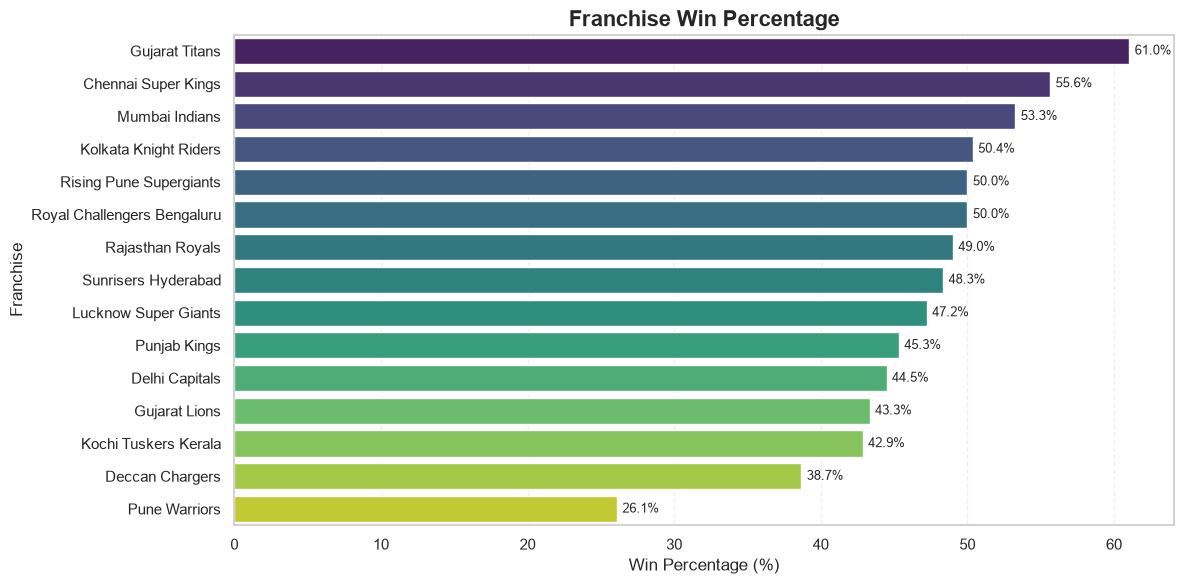

In [55]:
# ==========================================================
# 8.2 Franchise Win Percentage
# ==========================================================

# Teams batting first
team1 = (
    matches["team1"]
    .value_counts()
    .rename("Matches Played")
)

# Teams batting second
team2 = (
    matches["team2"]
    .value_counts()
    .rename("Matches Played")
)

# Total matches played
matches_played = (
    team1.add(team2, fill_value=0)
    .astype(int)
    .reset_index()
)

matches_played.columns = ["Team", "Matches Played"]

# Wins
wins = (
    matches["winner"]
    .dropna()
    .value_counts()
    .reset_index()
)

wins.columns = ["Team", "Wins"]

# Merge
team_stats = (
    matches_played
    .merge(wins, on="Team", how="left")
)

team_stats["Wins"] = (
    team_stats["Wins"]
    .fillna(0)
    .astype(int)
)

# Win Percentage
team_stats["Win Percentage"] = (
    team_stats["Wins"]
    / team_stats["Matches Played"]
    * 100
)

team_stats = (
    team_stats
    .sort_values("Win Percentage", ascending=False)
)

display(team_stats.round(2))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=team_stats,
    x="Win Percentage",
    y="Team",
    hue="Team",
    palette="viridis",
    legend=False
)

plt.title(
    "Franchise Win Percentage",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Win Percentage (%)")
plt.ylabel("Franchise")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/team_win_percentages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Outcome,Percentage
0,Won Match,51.56
1,Lost Match,48.44


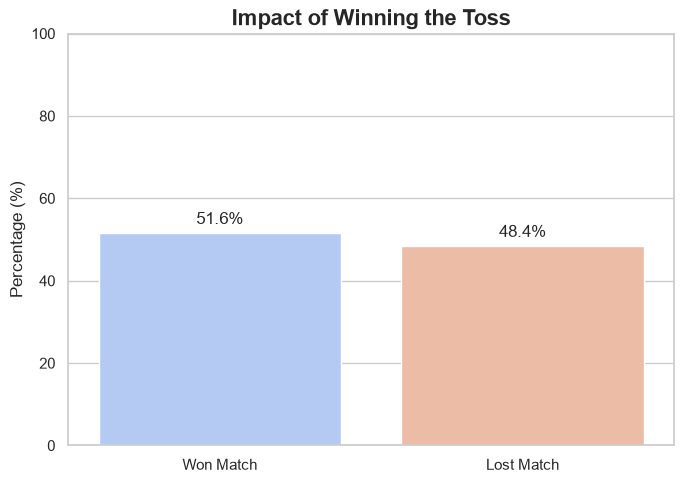

In [56]:
# ==========================================================
# 8.3 Toss Impact Analysis
# ==========================================================

# Remove matches without a valid winner
toss_df = matches.dropna(subset=["winner", "toss_winner"]).copy()

# Did the toss winner win the match?
toss_df["Toss Won Match"] = (
    toss_df["toss_winner"] == toss_df["winner"]
)

toss_stats = (
    toss_df["Toss Won Match"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={
        True: "Won Match",
        False: "Lost Match"
    })
    .reset_index()
)

toss_stats.columns = ["Outcome", "Percentage"]

display(toss_stats.round(2))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=toss_stats,
    x="Outcome",
    y="Percentage",
    hue="Outcome",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Impact of Winning the Toss",
    fontsize=16,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("Percentage (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

plt.ylim(0,100)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/toss_match_win_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Win Type,Matches
0,Chased (Bat Second),610
1,Defended (Bat First),608
2,No Result,25


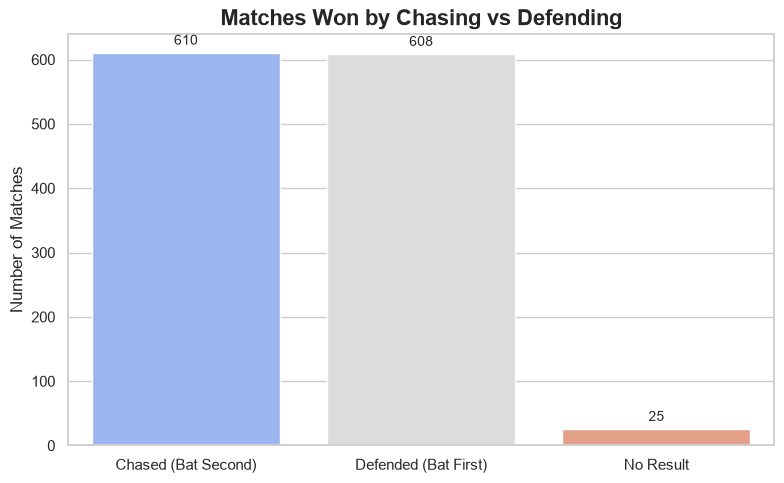

In [57]:
# ==========================================================
# 8.4 Chasing vs Defending Analysis
# ==========================================================

# Determine whether the winning team batted first or second
def get_win_type(row):

    if pd.isna(row["winner"]):
        return "No Result"

    if row["winner"] == row["team1"]:
        return "Defended (Bat First)"

    elif row["winner"] == row["team2"]:
        return "Chased (Bat Second)"

    return "Other"

matches["Win Type"] = matches.apply(get_win_type, axis=1)

win_type = (
    matches["Win Type"]
    .value_counts()
    .reset_index()
)

win_type.columns = ["Win Type", "Matches"]

display(win_type)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=win_type,
    x="Win Type",
    y="Matches",
    hue="Win Type",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Matches Won by Chasing vs Defending",
    fontsize=16,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Matches")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=4,
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/chasing_vs_defending.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- This analysis compares the success of teams batting first versus teams chasing a target.
- A higher percentage of wins while chasing suggests that teams benefit from knowing the target before batting.
- Conversely, if defending teams dominate, it indicates that setting a competitive total provides a strategic advantage.
- These findings can help evaluate match strategies and the influence of match conditions on outcomes.

# 9. Venue Analysis

## 9.1 Highest Scoring Venues

Different venues offer different playing conditions, influencing batting performance and match outcomes.

This analysis calculates the **average first-innings score** at each venue to identify the most batting-friendly grounds in IPL history.

To ensure meaningful comparisons, only venues that have hosted at least **15 matches** are included.

,venue,Average_Score,Matches
13,Himachal Pradesh Cricket Association Stadium,191.2,19
19,Maharaja Yadavindra Singh International Cricke...,186.6,17
21,Narendra Modi Stadium,185.8,41
0,Arun Jaitley Stadium,185.6,44
4,Brabourne Stadium,178.5,27
26,Punjab Cricket Association IS Bindra Stadium,175.0,26
3,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,174.8,29
17,M Chinnaswamy Stadium,174.1,104
39,Wankhede Stadium,173.1,132
8,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,169.5,17


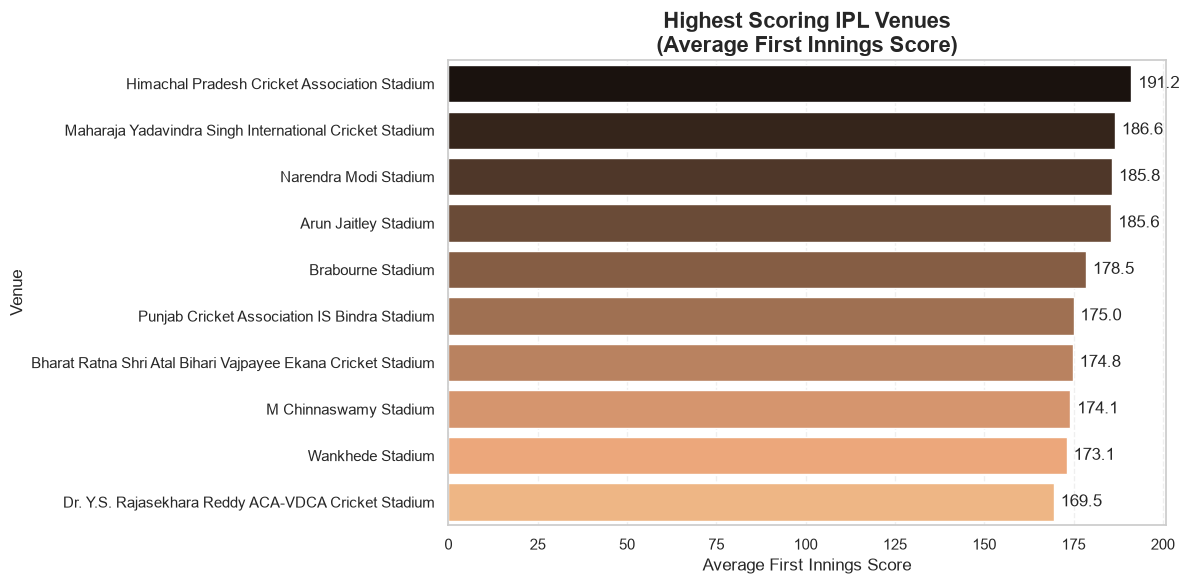

In [59]:
# ==========================================================
# 9.1 Highest Scoring Venues
# ==========================================================

# First innings total for every match
first_innings = (
    deliveries[
        deliveries["innings"] == 1
    ]
    .groupby("match_id", as_index=False)
    .agg(
        First_Innings_Score=("runs_total", "sum")
    )
)

# Merge venue information
venue_scores = (
    first_innings.merge(
        matches[["match_id", "venue"]],
        on="match_id",
        how="left"
    )
)

# Venue statistics
venue_stats = (
    venue_scores
    .groupby("venue", as_index=False)
    .agg(
        Average_Score=("First_Innings_Score", "mean"),
        Matches=("match_id", "count")
    )
)

# Filter venues
top_venues = (
    venue_stats[
        venue_stats["Matches"] >= 15
    ]
    .sort_values(
        "Average_Score",
        ascending=False
    )
    .head(10)
)

top_venues["Average_Score"] = (
    top_venues["Average_Score"]
    .round(1)
)

display(top_venues)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_venues,
    x="Average_Score",
    y="venue",
    hue="venue",
    palette="copper",
    legend=False
)

plt.title(
    "Highest Scoring IPL Venues\n(Average First Innings Score)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Average First Innings Score")
plt.ylabel("Venue")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=5
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/highest_scoring_venues.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Win Type,venue,Matches,Defended (Bat First),Chased (Bat Second),Chasing Win %
36,Subrata Roy Sahara Stadium,16,4,12,75.00
8,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,17,6,11,64.71
33,Sharjah Cricket Stadium,28,10,18,64.29
34,Sheikh Zayed Stadium,27,10,17,62.96
3,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,27,11,16,59.26
26,Punjab Cricket Association IS Bindra Stadium,26,11,15,57.69
11,Feroz Shah Kotla,59,26,33,55.93
7,Dr DY Patil Sports Academy,37,17,20,54.05
19,Maharaja Yadavindra Singh International Cricke...,17,8,9,52.94
0,Arun Jaitley Stadium,42,20,22,52.38


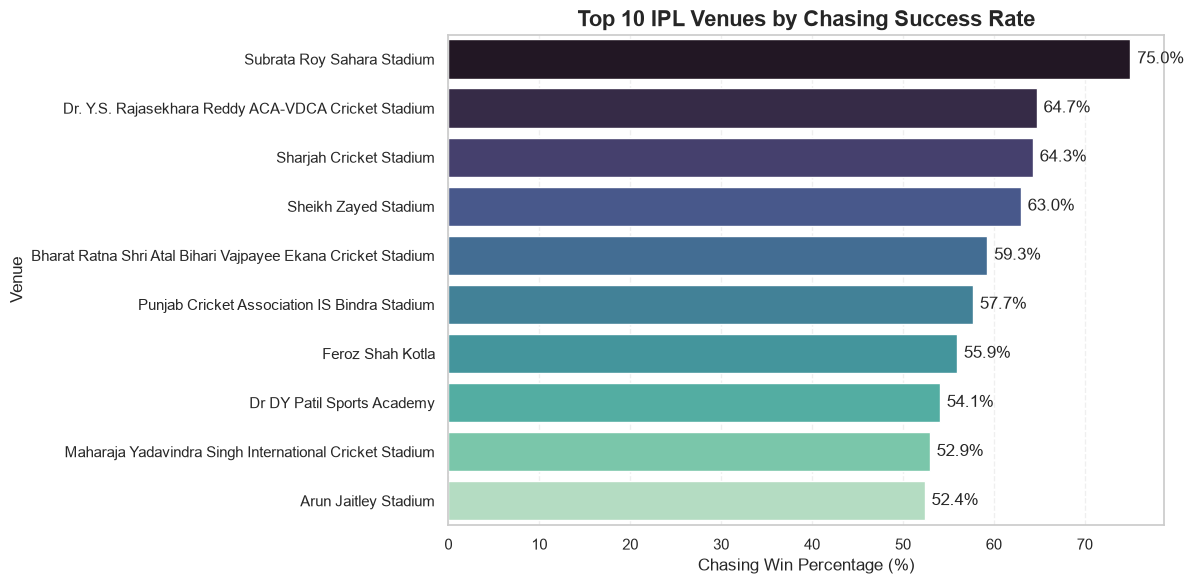

In [60]:
# ==========================================================
# 9.2 Best Venues for Chasing
# ==========================================================

# Create venue vs win type table
venue_results = (
    matches.groupby(["venue", "Win Type"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in ["Defended (Bat First)", "Chased (Bat Second)"]:
    if col not in venue_results.columns:
        venue_results[col] = 0

venue_results = venue_results.reset_index()

# Total completed matches
venue_results["Matches"] = (
    venue_results["Defended (Bat First)"] +
    venue_results["Chased (Bat Second)"]
)

# Filter venues with at least 15 matches
qualified_venues = (
    venue_results[
        venue_results["Matches"] >= 15
    ].copy()
)

# Chasing Success Percentage
qualified_venues["Chasing Win %"] = (
    qualified_venues["Chased (Bat Second)"] /
    qualified_venues["Matches"]
) * 100

# Top venues
top_chasing = (
    qualified_venues
    .sort_values(
        "Chasing Win %",
        ascending=False
    )
    .head(10)
)

display(
    top_chasing[
        [
            "venue",
            "Matches",
            "Defended (Bat First)",
            "Chased (Bat Second)",
            "Chasing Win %"
        ]
    ].round(2)
)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_chasing,
    x="Chasing Win %",
    y="venue",
    hue="venue",
    palette="mako",
    legend=False
)

plt.title(
    "Top 10 IPL Venues by Chasing Success Rate",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Chasing Win Percentage (%)")
plt.ylabel("Venue")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/best_chasing_venues.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Key Insights: Venue Analysis

Based on the venue-level analysis, the following observations were made:

### 1. High-Scoring Venues
- Certain venues consistently recorded higher average first-innings scores, indicating batting-friendly playing conditions.
- These grounds typically provide good batting surfaces, shorter boundaries, or conditions that favor stroke play.

### 2. Bowling-Friendly Venues
- Some venues exhibited lower average first-innings scores, suggesting conditions that assist bowlers through pace, bounce, or spin.
- Teams playing at these venues may prioritize defending moderate totals rather than relying on high scores.

### 3. Chasing Advantage
- The venue-wise chasing analysis shows that the success rate of chasing varies significantly across different stadiums.
- At some venues, teams batting second achieved considerably higher win percentages, while other grounds favored teams defending a target.

### 4. Strategic Importance of Venue
- Venue characteristics influence several aspects of the game, including batting performance, bowling effectiveness, toss decisions, and match strategy.
- Understanding venue behavior enables teams to make more informed decisions regarding team selection and match tactics.

### Overall Conclusion
Venue conditions have a measurable impact on IPL matches. Evaluating scoring patterns together with chasing success provides valuable insights into how different stadiums influence match outcomes and team strategies.

# 10. Match Progression Analysis

## Objective

Understanding how an innings progresses is essential for identifying scoring patterns and wicket-taking opportunities in T20 cricket.

This section analyzes the progression of an innings by examining:

- Average runs scored in each over.
- Wickets lost in each over.
- Scoring trends from the Powerplay to the Death Overs.

The objective is to understand how batting and bowling strategies evolve throughout an innings and identify the overs that have the greatest impact on the final result.

,over,Average_Runs
0,0,6.40
1,1,7.65
2,2,8.42
3,3,8.68
4,4,8.69
5,5,8.73
6,6,7.03
7,7,7.51
8,8,7.80
9,9,7.68


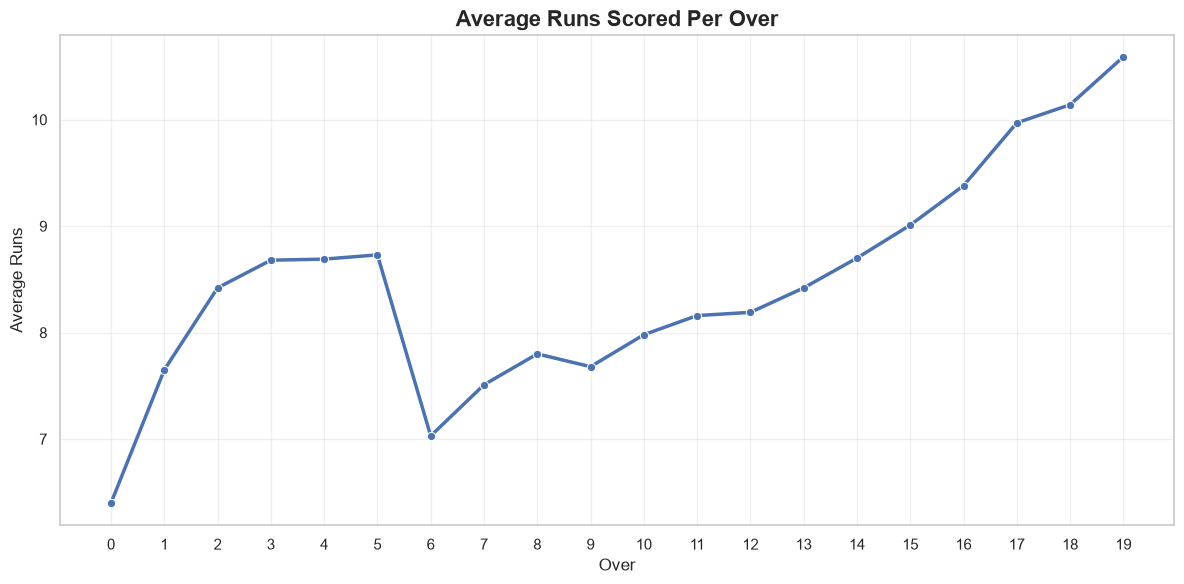

In [61]:
# ==========================================================
# 10.1 Average Runs Scored Per Over
# ==========================================================

# Runs scored in every over of every innings
runs_per_over = (
    deliveries.groupby(
        ["match_id", "innings", "over"],
        as_index=False
    )
    .agg(
        Runs=("runs_total", "sum")
    )
)

# Average over all matches
avg_runs = (
    runs_per_over.groupby(
        "over",
        as_index=False
    )
    .agg(
        Average_Runs=("Runs", "mean")
    )
)

avg_runs["Average_Runs"] = avg_runs["Average_Runs"].round(2)

display(avg_runs)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=avg_runs,
    x="over",
    y="Average_Runs",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Average Runs Scored Per Over",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Over")
plt.ylabel("Average Runs")

plt.grid(alpha=0.3)

plt.xticks(range(0,20))

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/average_runs_per_over.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,over,Wickets
0,0,533
1,1,578
2,2,629
3,3,617
4,4,653
5,5,604
6,6,509
7,7,545
8,8,610
9,9,568


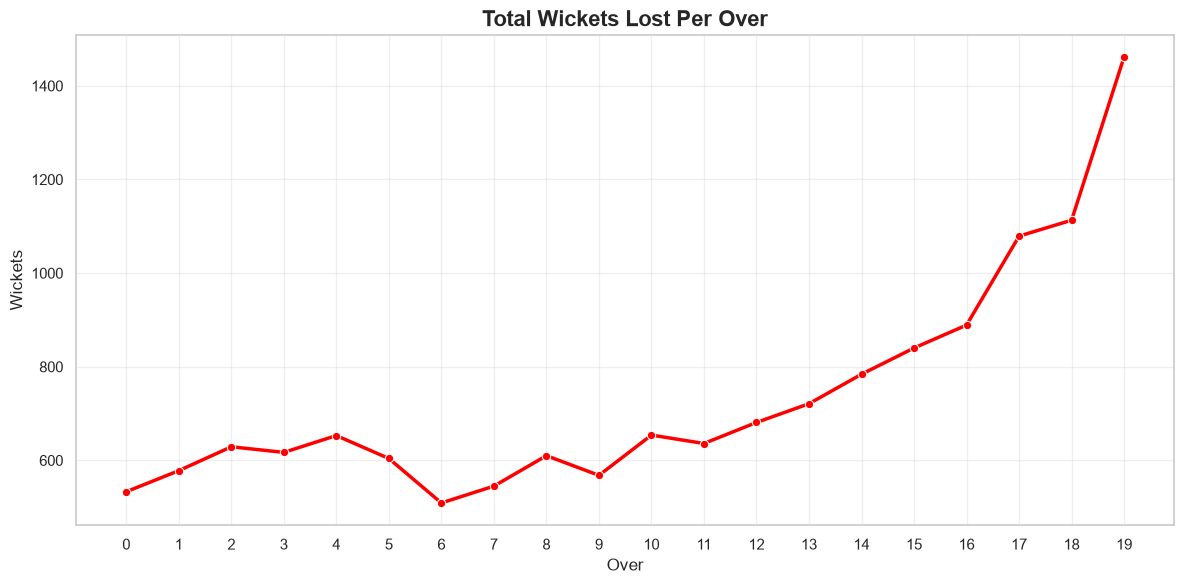

In [63]:
# ==========================================================
# 10.2 Wickets Lost Per Over
# ==========================================================

wickets_per_over = (
    deliveries.groupby(
        "over",
        as_index=False
    )
    .agg(
        Wickets=("wicket", "sum")
    )
)

display(wickets_per_over)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=wickets_per_over,
    x="over",
    y="Wickets",
    marker="o",
    linewidth=2.5,
    color="red"
)

plt.title(
    "Total Wickets Lost Per Over",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Over")
plt.ylabel("Wickets")

plt.grid(alpha=0.3)

plt.xticks(range(0,20))

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/wickets_per_over.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Insight

- Run scoring generally increases as the innings progresses.
- Teams typically score at a moderate pace during the early overs before accelerating during the final overs.
- The Death Overs usually produce the highest scoring rates due to aggressive batting.
- Wickets are generally distributed throughout the innings but tend to increase during the later overs.
- As batters accelerate their scoring towards the end of an innings, the risk of dismissal also increases.
- This illustrates the trade-off between aggressive scoring and wicket preservation in T20 cricket.

## 11. Advanced Cricket Insights (The Cool Stuff!)

Let's build a couple of fun, high-level sports analysis tools:
1. **Batter vs. Bowler Matchup Analyzer**: A simple Python function that queries how any batsman does against any bowler face-to-face.
2. **Powerplay win correlation**: Check if scoring 50+ runs in the first 6 overs helps you win.
3. **Successful Partnerships**: Which batting duos have scored the most total runs together?


In [70]:
# ==========================================================
# 11.1 Batter vs Bowler Matchup Analysis
# ==========================================================

def batter_vs_bowler(batter_name, bowler_name):

    matchup = deliveries[
        (deliveries["batter"] == batter_name) &
        (deliveries["bowler"] == bowler_name)
    ]

    if matchup.empty:
        print(f"No records found for {batter_name} vs {bowler_name}.")
        return None

    runs = matchup["runs_batter"].sum()
    balls = len(matchup)

    dismissals = (
        matchup["wicket_player_out"]
        .eq(batter_name)
        .sum()
    )

    strike_rate = (runs / balls) * 100 if balls > 0 else 0

    batting_average = (
        runs / dismissals
        if dismissals > 0
        else np.nan
    )

    result = pd.DataFrame({
        "Batter":[batter_name],
        "Bowler":[bowler_name],
        "Runs":[runs],
        "Balls":[balls],
        "Strike Rate":[round(strike_rate,2)],
        "Dismissals":[dismissals],
        "Average":[round(batting_average,2) if dismissals > 0 else np.nan]
    })

    return result






,Powerplay Range,Innings,Wins,Win Percentage
4,<35,390,113,28.97
0,35-44,626,273,43.61
1,45-54,745,360,48.32
2,55-64,483,280,57.97
3,65+,270,192,71.11


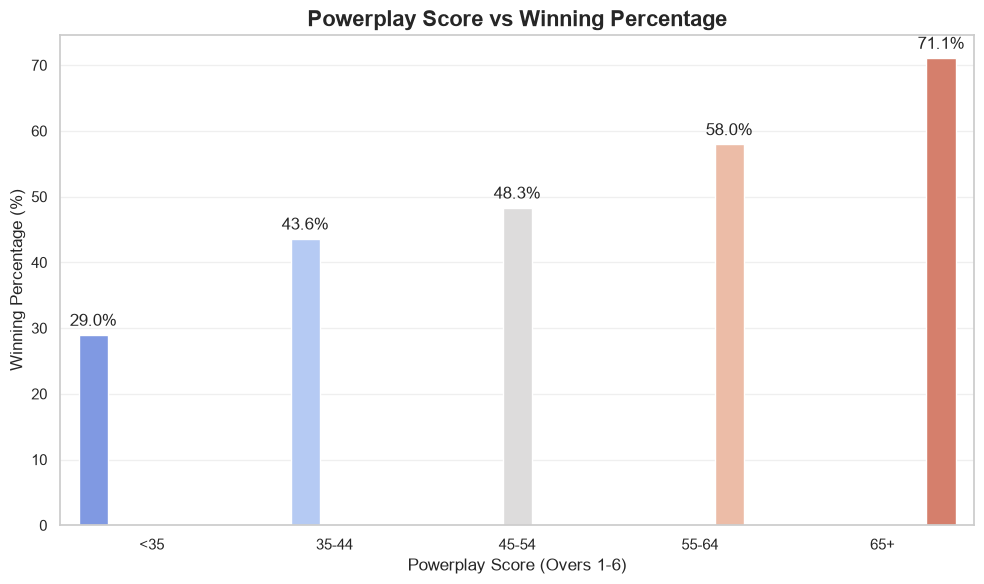

In [72]:
# ==========================================================
# 11.2 Powerplay Score vs Match Outcome
# ==========================================================

# Powerplay (Overs 1-6)
powerplay = (
    deliveries[
        deliveries["over"] <= 5
    ]
    .groupby(
        ["match_id", "innings", "batting_team"],
        as_index=False
    )
    .agg(
        Powerplay_Runs=("runs_total", "sum")
    )
)

# Match winners
powerplay = powerplay.merge(
    matches[
        ["match_id", "winner"]
    ],
    on="match_id",
    how="left"
)

# Did this innings belong to the winning team?
powerplay["Won"] = (
    powerplay["batting_team"] ==
    powerplay["winner"]
)

# ----------------------------------------------------------
# Score Buckets
# ----------------------------------------------------------

def score_bucket(score):

    if score < 35:
        return "<35"

    elif score < 45:
        return "35-44"

    elif score < 55:
        return "45-54"

    elif score < 65:
        return "55-64"

    else:
        return "65+"

powerplay["Powerplay Range"] = (
    powerplay["Powerplay_Runs"]
    .apply(score_bucket)
)

# ----------------------------------------------------------
# Win Percentage
# ----------------------------------------------------------

pp_stats = (
    powerplay.groupby(
        "Powerplay Range",
        as_index=False
    )
    .agg(
        Innings=("Won","count"),
        Wins=("Won","sum")
    )
)

pp_stats["Win Percentage"] = (
    pp_stats["Wins"] /
    pp_stats["Innings"]
) * 100

# Correct order
order = [
    "<35",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

pp_stats["Powerplay Range"] = pd.Categorical(
    pp_stats["Powerplay Range"],
    categories=order,
    ordered=True
)

pp_stats = pp_stats.sort_values(
    "Powerplay Range"
)

display(pp_stats.round(2))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=pp_stats,
    x="Powerplay Range",
    y="Win Percentage",
    hue="Powerplay Range",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Powerplay Score vs Winning Percentage",
    fontsize=16,
    weight="bold"
)

plt.xlabel(
    "Powerplay Score (Overs 1-6)"
)

plt.ylabel(
    "Winning Percentage (%)"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/powerplay_win_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Partnership,Runs
381,AB de Villiers & V Kohli,3134
1297,B Sai Sudharsan & Shubman Gill,2966
1619,CH Gayle & V Kohli,2802
1929,DA Warner & S Dhawan,2357
2416,F du Plessis & V Kohli,2032
1817,D Padikkal & V Kohli,2024
2452,G Gambhir & RV Uthappa,1906
1007,Abhishek Sharma & TM Head,1892
2869,Ishan Kishan & RG Sharma,1868
3520,KL Rahul & MA Agarwal,1731


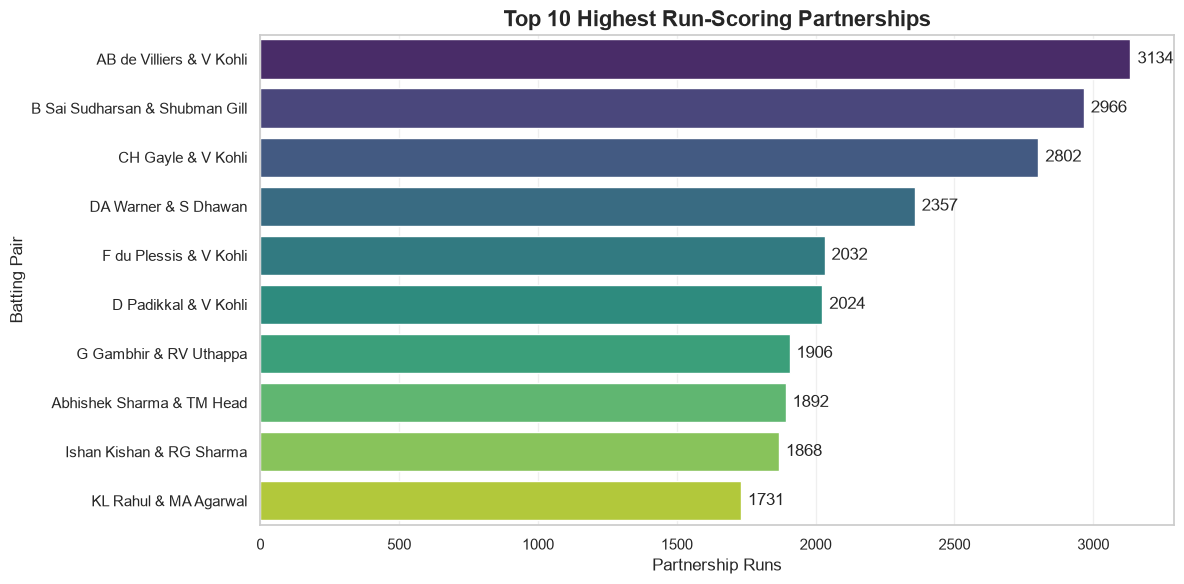

In [73]:
# ==========================================================
# 11.3 Highest Batting Partnerships
# ==========================================================

# Create a consistent partnership name
deliveries["Partnership"] = deliveries.apply(
    lambda row: " & ".join(
        sorted([row["batter"], row["non_striker"]])
    ),
    axis=1
)

# Partnership runs
partnerships = (
    deliveries.groupby(
        "Partnership",
        as_index=False
    )
    .agg(
        Runs=("runs_total", "sum")
    )
)

# Top 10
top_partnerships = (
    partnerships
    .sort_values(
        "Runs",
        ascending=False
    )
    .head(10)
)

display(top_partnerships)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_partnerships,
    x="Runs",
    y="Partnership",
    hue="Partnership",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Highest Run-Scoring Partnerships",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Partnership Runs")
plt.ylabel("Batting Pair")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=5
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/top_partnerships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Key Insights: Advanced Cricket Analytics

Based on the advanced analyses, the following observations were made:

### 1. Batter vs Bowler Matchups
- Head-to-head analysis highlights how individual player matchups can influence performance.
- Some bowlers consistently restrict particular batters by limiting their scoring rate and dismissing them more frequently.
- These insights can help teams make informed tactical decisions regarding bowling changes and batting order.

### 2. Powerplay Performance
- Teams with higher Powerplay scores generally achieved higher winning percentages.
- A strong start provides momentum and creates a solid foundation for the remainder of the innings.
- However, Powerplay performance alone does not guarantee victory, as middle-over partnerships, death-over execution, and bowling performance also influence the final result.

### 3. Batting Partnerships
- Long-standing batting partnerships have contributed significantly to team success by consistently building large totals.
- Strong partnerships reduce scoreboard pressure, stabilize the innings, and increase the likelihood of posting or chasing competitive scores.

### Overall Conclusion
Advanced cricket analytics demonstrates that match outcomes are influenced by a combination of individual player matchups, team strategies, and batting partnerships. Analyzing these factors together provides deeper insights than traditional statistics alone and supports more informed decision-making.

# 12. Conclusion & Key Takeaways

## Project Summary

This project presented a complete end-to-end Exploratory Data Analysis (EDA) of Indian Premier League (IPL) data spanning multiple seasons. Using Python and its data analysis libraries, raw cricket data was transformed into meaningful insights through data cleaning, statistical analysis, and visualization.

The project covered player performance, team performance, venue characteristics, match progression, and advanced cricket analytics to understand the factors that influence success in T20 cricket.

---

## Key Takeaways

### 1. Importance of Data Preparation
- Data cleaning and preprocessing formed the foundation of the analysis.
- Handling missing values, removing duplicate records, and standardizing datasets were essential steps before performing meaningful analysis.

### 2. Batting Performance
- Batting success cannot be measured using a single statistic.
- Combining metrics such as total runs, strike rate, batting average, boundary percentage, and milestones provides a comprehensive evaluation of player performance.

### 3. Bowling Performance
- Effective bowlers consistently combine wicket-taking ability with economical bowling and pressure creation through dot balls.
- Evaluating multiple bowling metrics provides a more balanced assessment than relying solely on wicket counts.

### 4. Team & Venue Performance
- Team success depends on long-term consistency rather than isolated performances.
- Venue conditions significantly influence scoring patterns, chasing success, and overall match strategy.

### 5. Match Progression
- Scoring patterns change throughout an innings, with batting becoming progressively more aggressive during the death overs.
- Understanding these trends provides valuable insights into team strategy and match dynamics.

### 6. Advanced Analytics
- Player matchups, Powerplay performance, and batting partnerships provide deeper insights beyond traditional cricket statistics.
- These analyses demonstrate how historical data can support tactical decision-making in sports.

---

# Skills Demonstrated

Throughout this project, the following data analytics skills were applied:

- Data Collection and Preparation
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Data Visualization
- Feature Engineering
- Business Insight Generation
- Data Storytelling
- Python Programming (Pandas, NumPy, Matplotlib, Seaborn)

---

# Final Conclusion

This project demonstrates a complete real-world data analytics workflow—from importing raw data and preparing it for analysis to generating visualizations and interpreting actionable insights.

Beyond cricket analytics, the techniques used in this project are directly applicable to business analytics, financial reporting, customer behavior analysis, and operational decision-making.

This project serves as a strong portfolio example showcasing practical data analysis, visualization, and storytelling skills using Python and real-world datasets.